# Deep fake classification with transfer learning: EfficientNet base

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Imports

In [2]:
#Graphics
import numpy as np

import matplotlib.pyplot as plt
%matplotlib inline

#Keras
from keras.models import Model
from keras import Input, layers, optimizers, callbacks

from keras.utils import image_dataset_from_directory

#Pretrained model for transfer learning
from keras.applications.efficientnet import EfficientNetB3, preprocess_input

#Saving models
import joblib

## Location of the data

In [3]:
#Lightweight dataset
train_data_dir = "/content/drive/MyDrive/dfake_data_light/train/"
val_data_dir = "/content/drive/MyDrive/dfake_data_light/valid/"
test_data_dir = "/content/drive/MyDrive/dfake_data_light/test/"

## Parameters

In [4]:
BATCH_SIZE = 128
IMAGE_SIZE = (256, 256)
IMAGE_HEIGHT = IMAGE_SIZE[0]
IMAGE_WIDTH = IMAGE_SIZE[1]
NUM_CHANNELS = 3
SEED = 42
LEARNING_RATE = 0.001

## Creating datasets from directories

In [5]:
train_ds = image_dataset_from_directory(
    train_data_dir,
    labels="inferred",
    label_mode="binary",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE)


val_ds = image_dataset_from_directory(
    val_data_dir,
    labels="inferred",
    label_mode="binary",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE)

test_ds = image_dataset_from_directory(
    test_data_dir,
    labels="inferred",
    label_mode="binary",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE)

Found 10000 files belonging to 2 classes.
Found 2000 files belonging to 2 classes.
Found 2000 files belonging to 2 classes.


In [6]:
class_names = train_ds.class_names
print(class_names)

['fake', 'real']


In [7]:
def initialize_model(base_model):

    ######################
    ###  Architecture  ###
    ######################

    #Freezing weights of pretrained model
    base_model.trainable = False

    #Input
    inputs = Input(shape=(IMAGE_HEIGHT, IMAGE_WIDTH, NUM_CHANNELS))

    # x = data_augmentation(inputs)
    x = preprocess_input(inputs) #Preprocessing layer specifically designed for the pretrained model
    x = base_model(x) #Transfer learning model


    x = layers.Flatten()(x)

    #Dense layers
    x = layers.Dense(128, activation='relu')(x)
    # x = layers.Dropout(0.3)(x)
    x = layers.Dense(64, activation='relu')(x)
    # x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = Model(inputs=inputs, outputs=outputs)

    ################
    ##  Compiler  ##
    ################
    adam = optimizers.Adam(learning_rate=LEARNING_RATE)
    model.compile(loss='binary_crossentropy',
              optimizer=adam,
              metrics=['accuracy', 'recall', 'precision'])

    return model

In [8]:
base_model = EfficientNetB3(weights="imagenet", include_top=False, input_shape=(IMAGE_HEIGHT, IMAGE_WIDTH, NUM_CHANNELS))

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [9]:
model = initialize_model(base_model)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb3 (Functional)     │ (None, 8, 8, 1536)     │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 98304)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    12,583,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,374,896 (89.17 MB)

 Trainable params: 12,591,361 (48.03 MB)

 Non-trainable params: 10,783,535 (41.14 MB)

In [10]:
MODEL = 'dfake_efficientnet.keras'

modelCheckpoint = callbacks.ModelCheckpoint(MODEL,
                                            monitor="val_loss",
                                            verbose=0,
                                            save_best_only=True)

LRreducer = callbacks.ReduceLROnPlateau(monitor="val_loss",
                                        factor=0.1,
                                        patience=3,
                                        verbose=1,
                                        min_lr=0)

EarlyStopper = callbacks.EarlyStopping(monitor='val_loss',
                                       patience=3,
                                       verbose=0,
                                       restore_best_weights=True)

In [11]:
%%time
history = model.fit(train_ds,
                    epochs=10,
                    validation_data=val_ds,
                    callbacks=[modelCheckpoint, LRreducer, EarlyStopper],
                    verbose=1)

Epoch 1/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1432s 17s/step - accuracy: 0.6659 - loss: 1.1695 - precision: 0.6529 - recall: 0.6846 - val_accuracy: 0.8465 - val_loss: 0.3503 - val_precision: 0.8978 - val_recall: 0.7820 - learning_rate: 0.0010
Epoch 2/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 42s 526ms/step - accuracy: 0.8808 - loss: 0.2791 - precision: 0.8795 - recall: 0.8790 - val_accuracy: 0.8445 - val_loss: 0.3654 - val_precision: 0.9126 - val_recall: 0.7620 - learning_rate: 0.0010
Epoch 3/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 86s 579ms/step - accuracy: 0.9198 - loss: 0.1997 - precision: 0.9175 - recall: 0.9201 - val_accuracy: 0.8700 - val_loss: 0.3298 - val_precision: 0.9374 - val_recall: 0.7930 - learning_rate: 0.0010
Epoch 4/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 43s 536ms/step - accuracy: 0.9481 - loss: 0.1374 - precision: 0.9494 - recall: 0.9450 - val_accuracy: 0.8905 - val_loss: 0.2767 - val_precision: 0.8909 - val_recall: 0.8900 - learning_rate: 0.0010
Epoch 5/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 41s 512ms/step - accur

In [12]:
def plot_history(history):
    fig, ax = plt.subplots(1, 2, figsize=(15,5))
    ax[0].set_title('loss')
    ax[0].plot(history.epoch, history.history["loss"], label="Train loss")
    ax[0].plot(history.epoch, history.history["val_loss"], label="Validation loss")
    ax[1].set_title('accuracy')
    ax[1].plot(history.epoch, history.history["accuracy"], label="Train acc")
    ax[1].plot(history.epoch, history.history["val_accuracy"], label="Validation acc")
    ax[0].legend()
    ax[1].legend()

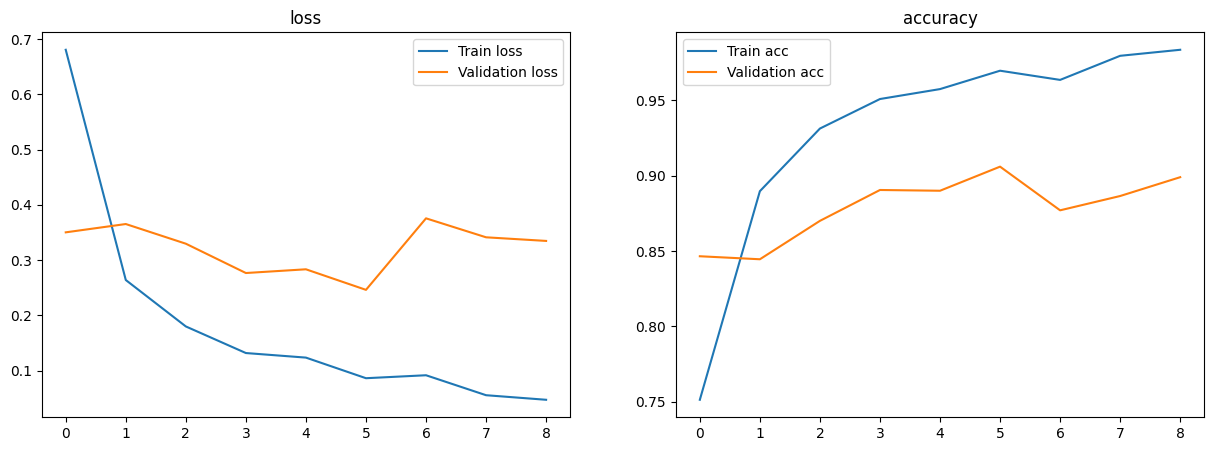

In [13]:
plot_history(history)

In [14]:
model.evaluate(test_ds)

16/16 ━━━━━━━━━━━━━━━━━━━━ 372s 23s/step - accuracy: 0.8952 - loss: 0.2658 - precision: 0.8900 - recall: 0.9009


[0.2771250009536743, 0.890999972820282, 0.8989999890327454, 0.8848425149917603]

In [1]:
import joblib

# model is your trained model
# joblib.dump(model, "/content/drive/MyDrive/dfake_models/efficientnet_v1.joblib")

In [2]:
model_1 = joblib.load('/home/thomas/code/dfake/dfake-models/training_outputs/models/efficientnet_v1.joblib')

2026-03-13 14:37:53.590066: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-13 14:37:53.852913: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-13 14:37:54.186353: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-13 14:37:54.516620: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-13 14:37:54.518700: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-13 14:37:55.027306: I tensorflow/core/platform/cpu_feature_guard.cc:

ValueError: Input 0 of layer "stem_conv" is incompatible with the layer: expected axis -1 of input shape to have value 3, but received input with shape (None, 257, 257, 1)

In [18]:
model_1.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb3 (Functional)     │ (None, 8, 8, 1536)     │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 98304)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    12,583,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 48,557,620 (185.23 MB)

 Trainable params: 12,591,361 (48.03 MB)

 Non-trainable params: 10,783,535 (41.14 MB)

 Optimizer params: 25,182,724 (96.06 MB)